Vértices: 12, Arestas do grafo: 20
Árvore gerada em 42 passos do walker
Arestas da árvore: [(0, 2), (0, 11), (0, 8), (0, 10), (1, 10), (1, 3), (1, 4), (2, 5), (2, 9), (5, 6), (7, 8)]


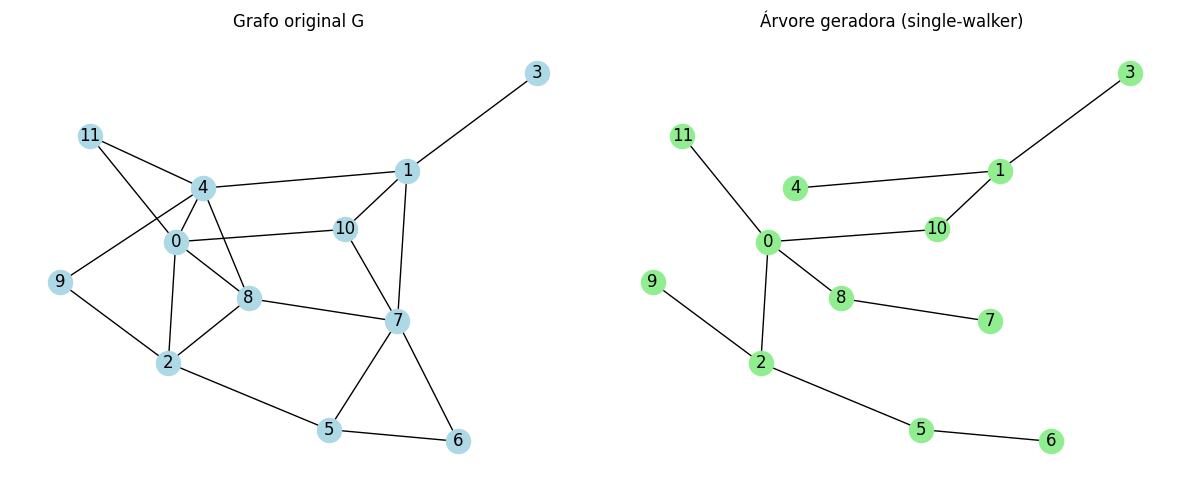

In [1]:
import networkx as nx
import random
import matplotlib.pyplot as plt

def single_walker_tree(G, start=None, seed=None):
    """
    Gera uma árvore geradora de G usando um único caminhante aleatório.
    A cada passo, o walker vai para um vizinho aleatório do vértice atual.
    Se o vizinho ainda não foi visitado, a aresta (atual -> vizinho) entra na árvore.
    """
    rng = random.Random(seed)

    if start is None:
        start = rng.choice(list(G.nodes()))

    visited = {start}
    tree_edges = []
    current = start
    steps = 0

    while len(visited) < G.number_of_nodes():
        neighbor = rng.choice(list(G.neighbors(current)))
        if neighbor not in visited:
            tree_edges.append((current, neighbor))
            visited.add(neighbor)
        current = neighbor
        steps += 1

    T = nx.Graph()
    T.add_nodes_from(G.nodes())
    T.add_edges_from(tree_edges)
    return T, steps


# ---------- Exemplo de uso ----------
# Cria um grafo conexo aleatório
n = 12
G = nx.erdos_renyi_graph(n, 0.25, seed=42)
while not nx.is_connected(G):
    G = nx.erdos_renyi_graph(n, 0.25, seed=random.randint(0, 10000))

T, num_passos = single_walker_tree(G, seed=7)

print(f"Vértices: {G.number_of_nodes()}, Arestas do grafo: {G.number_of_edges()}")
print(f"Árvore gerada em {num_passos} passos do walker")
print("Arestas da árvore:", list(T.edges()))

# ---------- Visualização ----------
pos = nx.spring_layout(G, seed=42)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

nx.draw(G, pos, ax=axes[0], with_labels=True, node_color="lightblue")
axes[0].set_title("Grafo original G")

nx.draw(T, pos, ax=axes[1], with_labels=True, node_color="lightgreen")
axes[1].set_title("Árvore geradora (single-walker)")

plt.tight_layout()
plt.show()

In [2]:
import numpy as np
import networkx as nx
import random

# ---------- Espaço de estados baseado em arcos ----------

def build_arcs(G):
    arcs = []
    for u, v in G.edges():
        arcs.append((u, v))
        arcs.append((v, u))
    arc_index = {a: i for i, a in enumerate(arcs)}
    return arcs, arc_index

def grover_coin(d):
    J = np.ones((d, d))
    return (2 / d) * J - np.eye(d)

def build_coin_operator(G, arcs, arc_index):
    dim = len(arcs)
    C = np.zeros((dim, dim), dtype=complex)
    for v in G.nodes():
        out_arcs = [(v, u) for u in G.neighbors(v)]
        d = len(out_arcs)
        if d == 0:
            continue
        idxs = [arc_index[a] for a in out_arcs]
        Cv = grover_coin(d)
        for i, gi in enumerate(idxs):
            for j, gj in enumerate(idxs):
                C[gi, gj] = Cv[i, j]
    return C

def build_shift_operator(arcs, arc_index):
    dim = len(arcs)
    S = np.zeros((dim, dim))
    for (u, v), i in arc_index.items():
        j = arc_index[(v, u)]
        S[j, i] = 1        # flip-flop shift: |u,v> -> |v,u>
    return S

def vertex_marginal(psi, arc_index, nodes):
    probs = np.abs(psi) ** 2
    vp = {v: 0.0 for v in nodes}
    for (u, v), i in arc_index.items():
        vp[u] += probs[i]  # posição = primeiro índice do arco
    return vp

# ---------- Caminhante quântico construindo a árvore ----------

def quantum_walker_tree(G, start=None, seed=None, coin_steps=1):
    rng = random.Random(seed)
    if start is None:
        start = rng.choice(list(G.nodes()))

    arcs, arc_index = build_arcs(G)
    C = build_coin_operator(G, arcs, arc_index)
    S = build_shift_operator(arcs, arc_index)
    U = S @ C

    dim = len(arcs)
    psi = np.zeros(dim, dtype=complex)
    d0 = G.degree[start]
    for u in G.neighbors(start):
        psi[arc_index[(start, u)]] = 1 / np.sqrt(d0)   # superposição inicial

    visited = {start}
    tree_edges = []
    tick = 0

    while len(visited) < G.number_of_nodes():
        for _ in range(coin_steps):
            psi = U @ psi                              # evolução unitária

        tick += 1
        vp = vertex_marginal(psi, arc_index, G.nodes())

        # fronteira: vértices não visitados adjacentes a algum já visitado
        frontier = [v for v in G.nodes() if v not in visited and
                    any(n in visited for n in G.neighbors(v))]
        if not frontier:
            break

        weights = np.array([vp[v] for v in frontier])
        if weights.sum() <= 1e-12:
            weights = np.ones(len(frontier))
        weights = weights / weights.sum()

        chosen = rng.choices(frontier, weights=weights, k=1)[0]  # "medição"
        parent = rng.choice([n for n in G.neighbors(chosen) if n in visited])

        tree_edges.append((parent, chosen))
        visited.add(chosen)

    T = nx.Graph()
    T.add_nodes_from(G.nodes())
    T.add_edges_from(tree_edges)
    return T, tick


# ---------- Exemplo ----------
n = 12
G = nx.erdos_renyi_graph(n, 0.25, seed=42)
while not nx.is_connected(G):
    G = nx.erdos_renyi_graph(n, 0.25, seed=random.randint(0, 10000))

T, ticks = quantum_walker_tree(G, seed=7, coin_steps=2)
print("Árvore gerada em", ticks, "ticks")
print("Arestas:", list(T.edges()))

Árvore gerada em 11 ticks
Arestas: [(0, 8), (0, 4), (0, 11), (1, 7), (1, 3), (2, 5), (2, 8), (4, 9), (5, 7), (5, 6), (7, 10)]


/var/folders/kc/45xbt9r57wvfwqj69r27v_rw0000gn/T/ipykernel_33388/3769694177.py:59: RuntimeWarning: divide by zero encountered in matmul
  U = S @ C
/var/folders/kc/45xbt9r57wvfwqj69r27v_rw0000gn/T/ipykernel_33388/3769694177.py:59: RuntimeWarning: overflow encountered in matmul
  U = S @ C
/var/folders/kc/45xbt9r57wvfwqj69r27v_rw0000gn/T/ipykernel_33388/3769694177.py:59: RuntimeWarning: invalid value encountered in matmul
  U = S @ C
/var/folders/kc/45xbt9r57wvfwqj69r27v_rw0000gn/T/ipykernel_33388/3769694177.py:73: RuntimeWarning: divide by zero encountered in matmul
  psi = U @ psi                              # evolução unitária
/var/folders/kc/45xbt9r57wvfwqj69r27v_rw0000gn/T/ipykernel_33388/3769694177.py:73: RuntimeWarning: overflow encountered in matmul
  psi = U @ psi                              # evolução unitária
/var/folders/kc/45xbt9r57wvfwqj69r27v_rw0000gn/T/ipykernel_33388/3769694177.py:73: RuntimeWarning: invalid value encountered in matmul
  psi = U @ psi                 

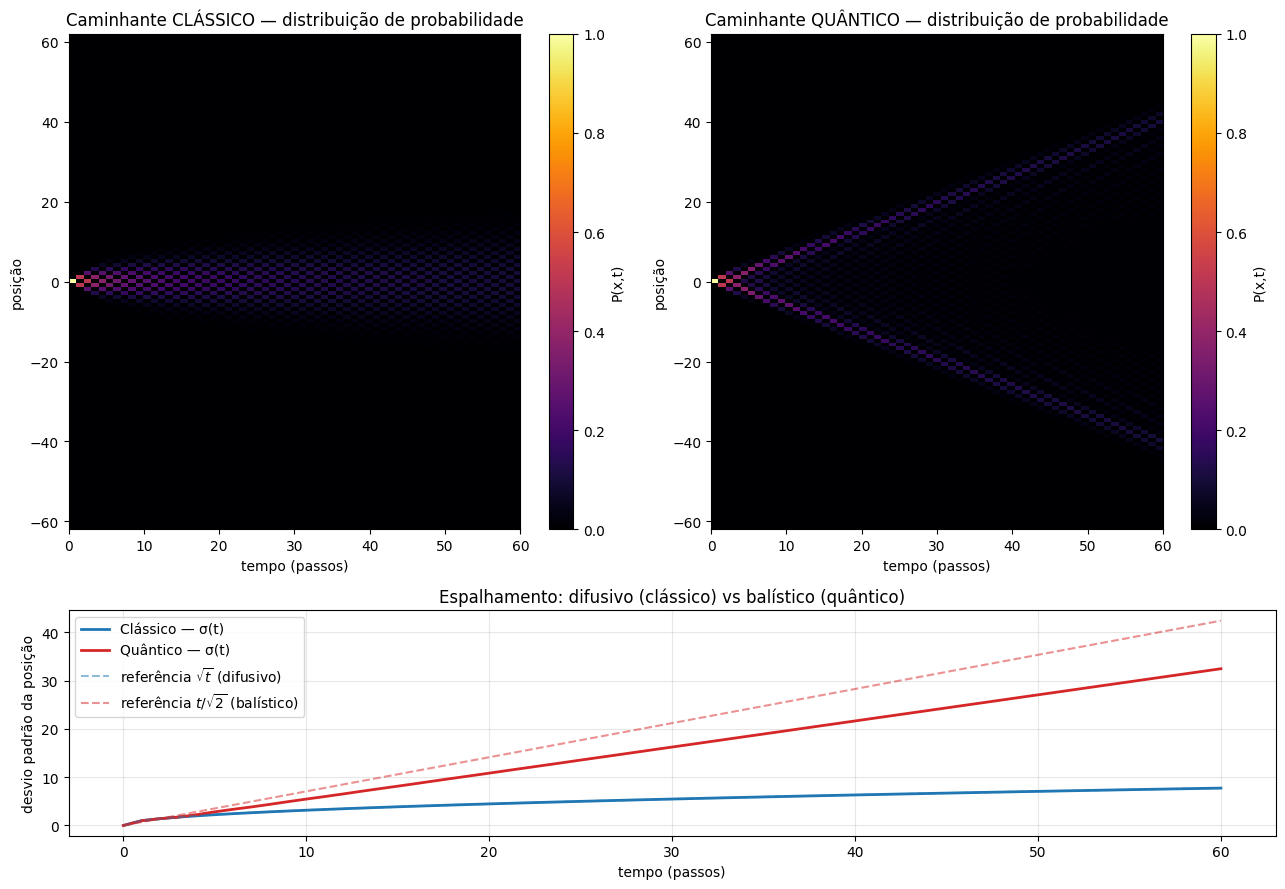

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Comparação didática: random walk clássico vs quantum walk (Hadamard coin)
# em um grafo caminho (path graph) -- o cenário padrão para visualizar
# a diferença fundamental: difusão (clássico) vs balístico (quântico)
# ============================================================

T = 60          # número de passos
N = T + 5       # tamanho do grid de posições (para não bater na borda)
positions = np.arange(-N, N + 1)
dim = len(positions)
center = N

# ---------------- Caminhante clássico ----------------
# P(x, t+1) = 0.5 P(x-1,t) + 0.5 P(x+1,t)
P_classical = np.zeros((dim, T + 1))
P_classical[center, 0] = 1.0
for t in range(T):
    P_classical[1:, t + 1]  += 0.5 * P_classical[:-1, t]
    P_classical[:-1, t + 1] += 0.5 * P_classical[1:, t]

# ---------------- Caminhante quântico (Hadamard coin, DTQW) ----------------
H = (1 / np.sqrt(2)) * np.array([[1, 1], [1, -1]])

psi = np.zeros((dim, 2), dtype=complex)
# estado inicial simétrico (evita viés para um dos lados)
psi[center, 0] = 1 / np.sqrt(2)
psi[center, 1] = 1j / np.sqrt(2)

P_quantum = np.zeros((dim, T + 1))
P_quantum[:, 0] = np.abs(psi[:, 0]) ** 2 + np.abs(psi[:, 1]) ** 2

for t in range(T):
    # 1) aplica o coin em cada posição
    coined = psi @ H.T   # (dim,2) @ (2,2)
    # 2) shift: coin=0 -> anda +1 ; coin=1 -> anda -1
    new_psi = np.zeros_like(psi)
    new_psi[1:, 0]  = coined[:-1, 0]
    new_psi[:-1, 1] = coined[1:, 1]
    psi = new_psi
    P_quantum[:, t + 1] = np.abs(psi[:, 0]) ** 2 + np.abs(psi[:, 1]) ** 2

# ---------------- Desvio padrão (espalhamento) ao longo do tempo ----------------
def std_over_time(P):
    stds = []
    for t in range(P.shape[1]):
        p = P[:, t]
        mean = np.sum(positions * p)
        var = np.sum((positions - mean) ** 2 * p)
        stds.append(np.sqrt(var))
    return np.array(stds)

std_c = std_over_time(P_classical)
std_q = std_over_time(P_quantum)

# ============================================================
# PLOTS
# ============================================================
fig = plt.figure(figsize=(13, 9))
gs = fig.add_gridspec(2, 2, height_ratios=[2.2, 1])

# --- Heatmap clássico ---
ax1 = fig.add_subplot(gs[0, 0])
window = slice(center - T - 2, center + T + 3)
im1 = ax1.imshow(P_classical[window, :], aspect='auto', origin='lower',
                  extent=[0, T, -T - 2, T + 2], cmap='inferno')
ax1.set_title("Caminhante CLÁSSICO — distribuição de probabilidade")
ax1.set_xlabel("tempo (passos)")
ax1.set_ylabel("posição")
fig.colorbar(im1, ax=ax1, label="P(x,t)")

# --- Heatmap quântico ---
ax2 = fig.add_subplot(gs[0, 1])
im2 = ax2.imshow(P_quantum[window, :], aspect='auto', origin='lower',
                  extent=[0, T, -T - 2, T + 2], cmap='inferno')
ax2.set_title("Caminhante QUÂNTICO — distribuição de probabilidade")
ax2.set_xlabel("tempo (passos)")
ax2.set_ylabel("posição")
fig.colorbar(im2, ax=ax2, label="P(x,t)")

# --- Espalhamento (std) comparado ---
ax3 = fig.add_subplot(gs[1, :])
t_axis = np.arange(T + 1)
ax3.plot(t_axis, std_c, label="Clássico — σ(t)", color="tab:blue", lw=2)
ax3.plot(t_axis, std_q, label="Quântico — σ(t)", color="tab:red", lw=2)
ax3.plot(t_axis, np.sqrt(t_axis), '--', color="tab:blue", alpha=0.5,
         label=r"referência $\sqrt{t}$ (difusivo)")
ax3.plot(t_axis, t_axis / np.sqrt(2), '--', color="tab:red", alpha=0.5,
         label=r"referência $t/\sqrt{2}$ (balístico)")
ax3.set_xlabel("tempo (passos)")
ax3.set_ylabel("desvio padrão da posição")
ax3.set_title("Espalhamento: difusivo (clássico) vs balístico (quântico)")
ax3.legend()
ax3.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("quantum_vs_classical_evolution.png", dpi=140)
plt.show()

/var/folders/kc/45xbt9r57wvfwqj69r27v_rw0000gn/T/ipykernel_33388/2390543419.py:95: RuntimeWarning: divide by zero encountered in matmul
  U = S @ C
/var/folders/kc/45xbt9r57wvfwqj69r27v_rw0000gn/T/ipykernel_33388/2390543419.py:95: RuntimeWarning: overflow encountered in matmul
  U = S @ C
/var/folders/kc/45xbt9r57wvfwqj69r27v_rw0000gn/T/ipykernel_33388/2390543419.py:95: RuntimeWarning: invalid value encountered in matmul
  U = S @ C
/var/folders/kc/45xbt9r57wvfwqj69r27v_rw0000gn/T/ipykernel_33388/2390543419.py:109: RuntimeWarning: divide by zero encountered in matmul
  psi = U @ psi
/var/folders/kc/45xbt9r57wvfwqj69r27v_rw0000gn/T/ipykernel_33388/2390543419.py:109: RuntimeWarning: overflow encountered in matmul
  psi = U @ psi
/var/folders/kc/45xbt9r57wvfwqj69r27v_rw0000gn/T/ipykernel_33388/2390543419.py:109: RuntimeWarning: invalid value encountered in matmul
  psi = U @ psi


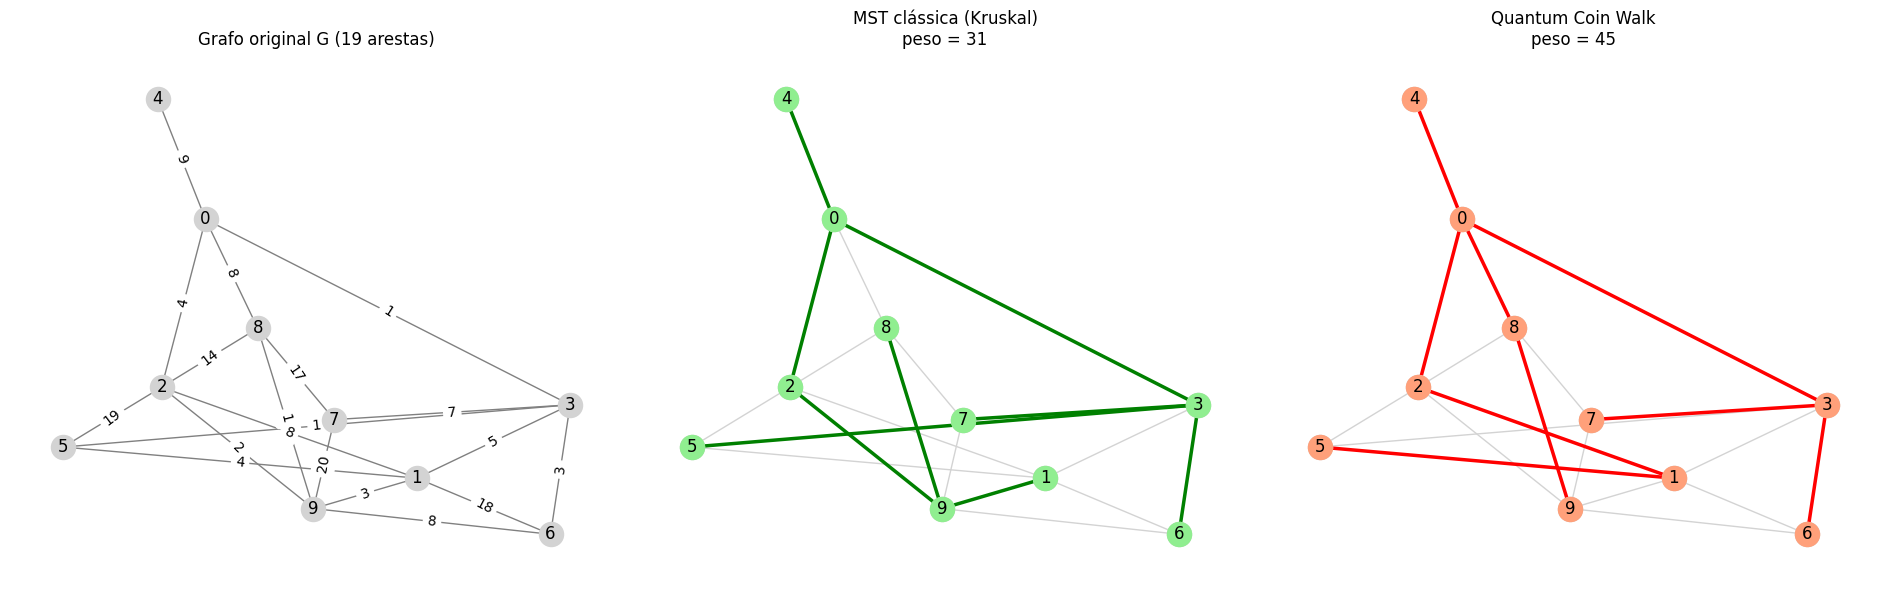

In [4]:
import numpy as np
import networkx as nx
import random
import matplotlib.pyplot as plt

SEED = 42
rng = random.Random(SEED)

# ====== 1) Grafo ponderado G = (V,E,w) ======
n = 10
G = nx.erdos_renyi_graph(n, 0.35, seed=SEED)
while not nx.is_connected(G):
    SEED += 1
    G = nx.erdos_renyi_graph(n, 0.35, seed=SEED)
for u, v in G.edges():
    G[u][v]['weight'] = rng.randint(1, 20)

# ====== 2) MST CLÁSSICA — Kruskal manual (union-find) ======
class UnionFind:
    def __init__(self, nodes):
        self.parent = {v: v for v in nodes}
    def find(self, x):
        while self.parent[x] != x:
            self.parent[x] = self.parent[self.parent[x]]
            x = self.parent[x]
        return x
    def union(self, a, b):
        ra, rb = self.find(a), self.find(b)
        if ra == rb: return False
        self.parent[ra] = rb
        return True

def kruskal_mst(G):
    edges = sorted(G.edges(data=True), key=lambda e: e[2]['weight'])
    uf = UnionFind(G.nodes())
    tree_edges = []
    for u, v, data in edges:
        if uf.union(u, v):
            tree_edges.append((u, v, data['weight']))
    return tree_edges

classical_edges = kruskal_mst(G)
classical_weight = sum(w for _, _, w in classical_edges)

# ====== 3) Árvore via QUANTUM COIN WALK ponderado ======
def build_arcs(G):
    arcs = []
    for u, v in G.edges():
        arcs.append((u, v)); arcs.append((v, u))
    return arcs, {a: i for i, a in enumerate(arcs)}

def weighted_grover_coin(weights):
    # amplitude ∝ 1/sqrt(peso) -> favorece arestas mais leves
    inv = 1.0 / np.array(weights, dtype=float)
    n = np.sqrt(inv); n = n / np.linalg.norm(n)
    return 2 * np.outer(n, n) - np.eye(len(weights))   # reflexão unitária

def build_coin_operator(G, arcs, arc_index):
    dim = len(arcs)
    C = np.zeros((dim, dim), dtype=complex)
    for v in G.nodes():
        out_arcs = [(v, u) for u in G.neighbors(v)]
        d = len(out_arcs)
        if d == 0: continue
        w = [G[v][u]['weight'] for u in G.neighbors(v)]
        idxs = [arc_index[a] for a in out_arcs]
        Cv = weighted_grover_coin(w)
        for i, gi in enumerate(idxs):
            for j, gj in enumerate(idxs):
                C[gi, gj] = Cv[i, j]
    return C

def build_shift_operator(arcs, arc_index):
    dim = len(arcs)
    S = np.zeros((dim, dim))
    for (u, v), i in arc_index.items():
        S[arc_index[(v, u)], i] = 1
    return S

def vertex_marginal(psi, arc_index, nodes):
    probs = np.abs(psi) ** 2
    vp = {v: 0.0 for v in nodes}
    for (u, v), i in arc_index.items():
        vp[u] += probs[i]
    return vp

def quantum_mst(G, start=None, seed=None, coin_steps=2):
    rng = random.Random(seed)
    if start is None:
        start = rng.choice(list(G.nodes()))

    arcs, arc_index = build_arcs(G)
    C = build_coin_operator(G, arcs, arc_index)
    S = build_shift_operator(arcs, arc_index)
    U = S @ C

    psi = np.zeros(len(arcs), dtype=complex)
    neigh = list(G.neighbors(start))
    w = np.array([G[start][u]['weight'] for u in neigh], dtype=float)
    amp = np.sqrt((1 / w) / np.sum(1 / w))
    for a, u in zip(amp, neigh):
        psi[arc_index[(start, u)]] = a

    visited = {start}
    tree_edges = []

    while len(visited) < G.number_of_nodes():
        for _ in range(coin_steps):
            psi = U @ psi

        vp = vertex_marginal(psi, arc_index, G.nodes())
        frontier = [v for v in G.nodes() if v not in visited and
                    any(x in visited for x in G.neighbors(v))]
        if not frontier:
            break

        wv = np.array([vp[v] for v in frontier])
        wv = wv / wv.sum() if wv.sum() > 1e-12 else np.ones(len(frontier)) / len(frontier)

        chosen = rng.choices(frontier, weights=wv, k=1)[0]
        candidates = [(x, G[chosen][x]['weight']) for x in G.neighbors(chosen) if x in visited]
        parent, wgt = min(candidates, key=lambda t: t[1])   # passo guloso estilo Prim

        tree_edges.append((parent, chosen, wgt))
        visited.add(chosen)

    return tree_edges

quantum_edges = quantum_mst(G, start=0, seed=7, coin_steps=2)
quantum_weight = sum(w for _, _, w in quantum_edges)

# ====== 4) Plot lado a lado ======
T_classical = nx.Graph(); T_classical.add_nodes_from(G.nodes()); T_classical.add_weighted_edges_from(classical_edges)
T_quantum  = nx.Graph(); T_quantum.add_nodes_from(G.nodes());  T_quantum.add_weighted_edges_from(quantum_edges)

pos = nx.spring_layout(G, seed=SEED)
fig, axes = plt.subplots(1, 3, figsize=(19, 6))

nx.draw(G, pos, ax=axes[0], with_labels=True, node_color="lightgray", edge_color="gray")
nx.draw_networkx_edge_labels(G, pos, edge_labels=nx.get_edge_attributes(G, 'weight'), ax=axes[0])
axes[0].set_title(f"Grafo original G ({G.number_of_edges()} arestas)")

nx.draw(G, pos, ax=axes[1], edge_color="lightgray", node_color="lightgray")
nx.draw(T_classical, pos, ax=axes[1], with_labels=True, node_color="lightgreen", edge_color="green", width=2.5)
axes[1].set_title(f"MST clássica (Kruskal)\npeso = {classical_weight}")

nx.draw(G, pos, ax=axes[2], edge_color="lightgray", node_color="lightgray")
nx.draw(T_quantum, pos, ax=axes[2], with_labels=True, node_color="lightsalmon", edge_color="red", width=2.5)
axes[2].set_title(f"Quantum Coin Walk\npeso = {quantum_weight}")

plt.tight_layout()
plt.savefig("mst_classica_vs_quantica.png", dpi=140)
plt.show()

/var/folders/kc/45xbt9r57wvfwqj69r27v_rw0000gn/T/ipykernel_33388/468679778.py:65: RuntimeWarning: divide by zero encountered in matmul
  U = S @ C
/var/folders/kc/45xbt9r57wvfwqj69r27v_rw0000gn/T/ipykernel_33388/468679778.py:65: RuntimeWarning: overflow encountered in matmul
  U = S @ C
/var/folders/kc/45xbt9r57wvfwqj69r27v_rw0000gn/T/ipykernel_33388/468679778.py:65: RuntimeWarning: invalid value encountered in matmul
  U = S @ C
/var/folders/kc/45xbt9r57wvfwqj69r27v_rw0000gn/T/ipykernel_33388/468679778.py:79: RuntimeWarning: divide by zero encountered in matmul
  psi = U @ psi
/var/folders/kc/45xbt9r57wvfwqj69r27v_rw0000gn/T/ipykernel_33388/468679778.py:79: RuntimeWarning: overflow encountered in matmul
  psi = U @ psi
/var/folders/kc/45xbt9r57wvfwqj69r27v_rw0000gn/T/ipykernel_33388/468679778.py:79: RuntimeWarning: invalid value encountered in matmul
  psi = U @ psi


start=0, seed=7, coin_steps=2       -> peso total = 45, arestas = [(0, 8), (0, 2), (0, 4), (2, 1), (8, 9), (1, 5), (0, 3), (3, 6), (3, 7)]
start=0, seed=99, coin_steps=2      -> peso total = 37, arestas = [(0, 8), (0, 2), (0, 3), (3, 5), (8, 9), (0, 4), (9, 1), (3, 6), (3, 7)]
start=5, seed=7, coin_steps=5       -> peso total = 42, arestas = [(5, 1), (5, 3), (1, 2), (3, 0), (0, 8), (3, 6), (0, 4), (8, 9), (3, 7)]

Todos os pesos iguais? False


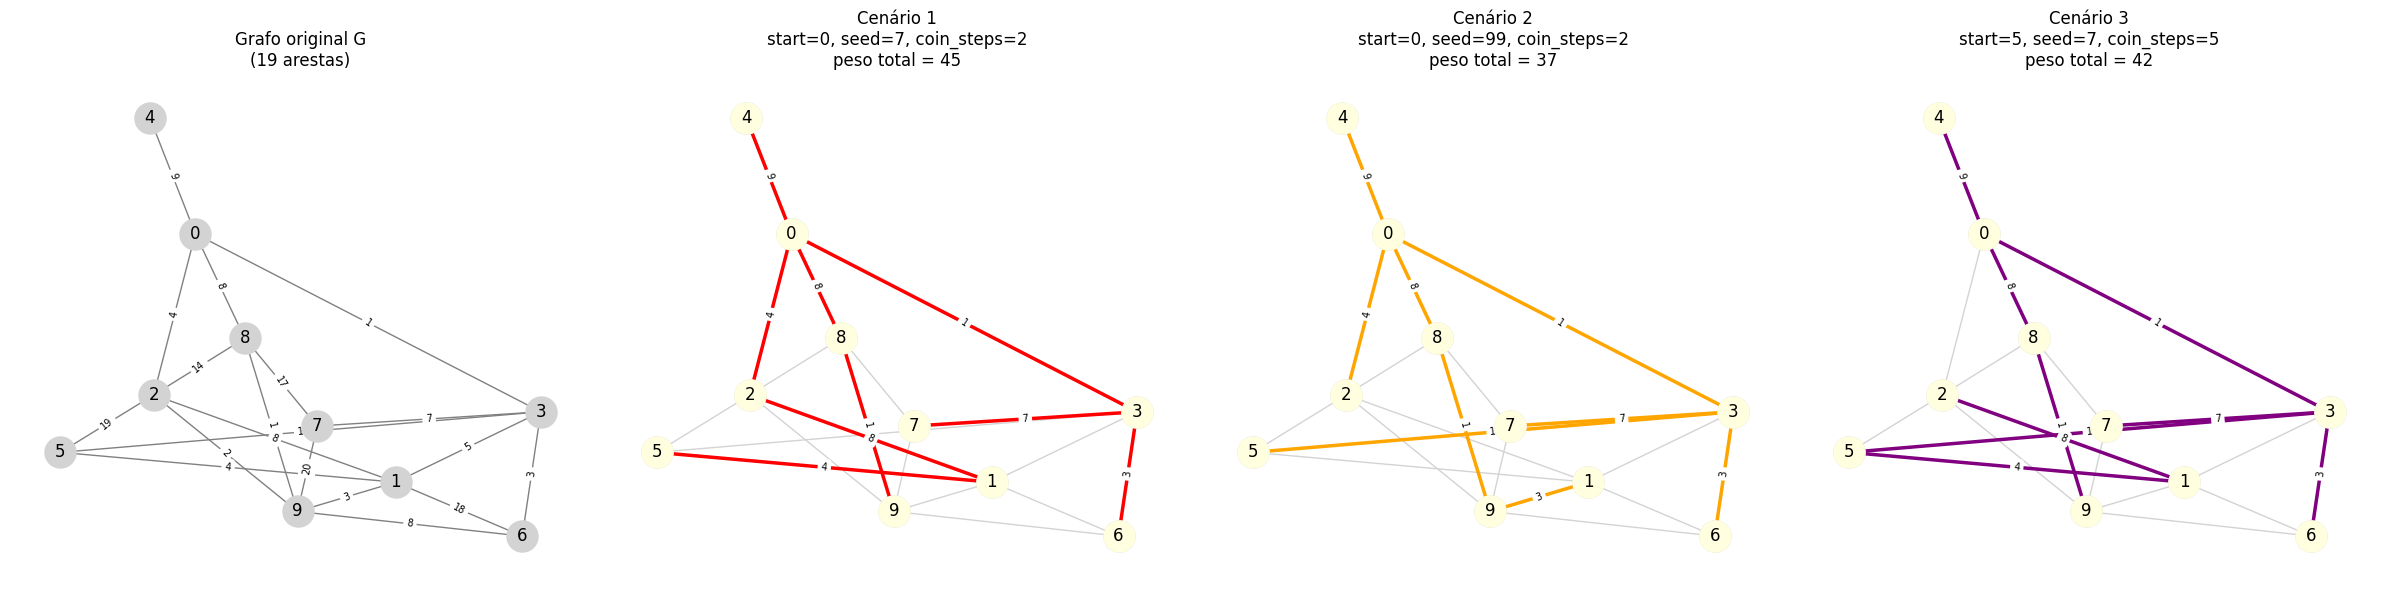

In [5]:
import numpy as np
import networkx as nx
import random
import matplotlib.pyplot as plt

SEED = 42
rng = random.Random(SEED)

# ====== Grafo ponderado (mesmo de antes, reconstruído igual) ======
n = 10
G = nx.erdos_renyi_graph(n, 0.35, seed=SEED)
while not nx.is_connected(G):
    SEED += 1
    G = nx.erdos_renyi_graph(n, 0.35, seed=SEED)
rng2 = random.Random(42)
for u, v in G.edges():
    G[u][v]['weight'] = rng2.randint(1, 20)

# ====== Funções do quantum coin walk ======
def build_arcs(G):
    arcs = []
    for u, v in G.edges():
        arcs.append((u, v)); arcs.append((v, u))
    return arcs, {a: i for i, a in enumerate(arcs)}

def weighted_grover_coin(weights):
    inv = 1.0 / np.array(weights, dtype=float)
    n_ = np.sqrt(inv); n_ = n_ / np.linalg.norm(n_)
    return 2 * np.outer(n_, n_) - np.eye(len(weights))

def build_coin_operator(G, arcs, arc_index):
    dim = len(arcs)
    C = np.zeros((dim, dim), dtype=complex)
    for v in G.nodes():
        out_arcs = [(v, u) for u in G.neighbors(v)]
        d = len(out_arcs)
        if d == 0: continue
        w = [G[v][u]['weight'] for u in G.neighbors(v)]
        idxs = [arc_index[a] for a in out_arcs]
        Cv = weighted_grover_coin(w)
        for i, gi in enumerate(idxs):
            for j, gj in enumerate(idxs):
                C[gi, gj] = Cv[i, j]
    return C

def build_shift_operator(arcs, arc_index):
    dim = len(arcs)
    S = np.zeros((dim, dim))
    for (u, v), i in arc_index.items():
        S[arc_index[(v, u)], i] = 1
    return S

def vertex_marginal(psi, arc_index, nodes):
    probs = np.abs(psi) ** 2
    vp = {v: 0.0 for v in nodes}
    for (u, v), i in arc_index.items():
        vp[u] += probs[i]
    return vp

def quantum_mst(G, start, seed, coin_steps=2):
    r = random.Random(seed)
    arcs, arc_index = build_arcs(G)
    C = build_coin_operator(G, arcs, arc_index)
    S = build_shift_operator(arcs, arc_index)
    U = S @ C

    psi = np.zeros(len(arcs), dtype=complex)
    neigh = list(G.neighbors(start))
    w = np.array([G[start][u]['weight'] for u in neigh], dtype=float)
    amp = np.sqrt((1 / w) / np.sum(1 / w))
    for a, u in zip(amp, neigh):
        psi[arc_index[(start, u)]] = a

    visited = {start}
    tree_edges = []

    while len(visited) < G.number_of_nodes():
        for _ in range(coin_steps):
            psi = U @ psi

        vp = vertex_marginal(psi, arc_index, G.nodes())
        frontier = [v for v in G.nodes() if v not in visited and
                    any(x in visited for x in G.neighbors(v))]
        if not frontier:
            break

        wv = np.array([vp[v] for v in frontier])
        wv = wv / wv.sum() if wv.sum() > 1e-12 else np.ones(len(frontier)) / len(frontier)

        chosen = r.choices(frontier, weights=wv, k=1)[0]
        candidates = [(x, G[chosen][x]['weight']) for x in G.neighbors(chosen) if x in visited]
        parent, wgt = min(candidates, key=lambda t: t[1])

        tree_edges.append((parent, chosen, wgt))
        visited.add(chosen)

    return tree_edges

# ====== 3 CENÁRIOS diferentes ======
scenarios = [
    {"label": "Cenário 1\nstart=0, seed=7, coin_steps=2",  "start": 0, "seed": 7,  "coin_steps": 2},
    {"label": "Cenário 2\nstart=0, seed=99, coin_steps=2", "start": 0, "seed": 99, "coin_steps": 2},
    {"label": "Cenário 3\nstart=5, seed=7, coin_steps=5",  "start": 5, "seed": 7,  "coin_steps": 5},
]

results = []
for sc in scenarios:
    edges = quantum_mst(G, start=sc["start"], seed=sc["seed"], coin_steps=sc["coin_steps"])
    weight = sum(w for _, _, w in edges)
    results.append((sc, edges, weight))
    print(f"{sc['label'].splitlines()[1]:35s} -> peso total = {weight}, arestas = {[(u,v) for u,v,w in edges]}")

pesos = [r[2] for r in results]
print("\nTodos os pesos iguais?", len(set(pesos)) == 1)

# ====== Plot: grafo original + 3 cenários ======
pos = nx.spring_layout(G, seed=42)
edge_labels = nx.get_edge_attributes(G, 'weight')

fig, axes = plt.subplots(1, 4, figsize=(24, 6))

nx.draw(G, pos, ax=axes[0], with_labels=True, node_color="lightgray", edge_color="gray", node_size=500)
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, ax=axes[0], font_size=7)
axes[0].set_title(f"Grafo original G\n({G.number_of_edges()} arestas)")

colors = ["red", "orange", "purple"]
for i, (sc, edges, weight) in enumerate(results):
    ax = axes[i + 1]
    T = nx.Graph()
    T.add_nodes_from(G.nodes())
    T.add_weighted_edges_from(edges)

    nx.draw(G, pos, ax=ax, edge_color="lightgray", node_color="lightgray", node_size=500)
    nx.draw(T, pos, ax=ax, with_labels=True, node_color="lightyellow",
            edge_color=colors[i], width=2.5, node_size=500)
    nx.draw_networkx_edge_labels(T, pos, edge_labels=nx.get_edge_attributes(T, 'weight'),
                                  ax=ax, font_size=7)
    ax.set_title(f"{sc['label']}\npeso total = {weight}")

plt.tight_layout()
plt.savefig("quantum_walk_3_cenarios.png", dpi=140)
plt.show()


===== MOEDA: HADAMARD =====
  Cenário 1 (start=0, seed=7, coin_steps=2) -> peso total = 67
  Cenário 2 (start=0, seed=99, coin_steps=2) -> peso total = 39
  Cenário 3 (start=5, seed=7, coin_steps=5) -> peso total = 60
  Pesos: [67, 39, 60]  | todos iguais? False

===== MOEDA: GROVER =====
  Cenário 1 (start=0, seed=7, coin_steps=2) -> peso total = 39
  Cenário 2 (start=0, seed=99, coin_steps=2) -> peso total = 39
  Cenário 3 (start=5, seed=7, coin_steps=5) -> peso total = 66
  Pesos: [39, 39, 66]  | todos iguais? False

===== MOEDA: CUSTOM =====
  Cenário 1 (start=0, seed=7, coin_steps=2) -> peso total = 62
  Cenário 2 (start=0, seed=99, coin_steps=2) -> peso total = 62
  Cenário 3 (start=5, seed=7, coin_steps=5) -> peso total = 58
  Pesos: [62, 62, 58]  | todos iguais? False


/var/folders/kc/45xbt9r57wvfwqj69r27v_rw0000gn/T/ipykernel_33388/1308086812.py:86: RuntimeWarning: divide by zero encountered in matmul
  U = S @ C
/var/folders/kc/45xbt9r57wvfwqj69r27v_rw0000gn/T/ipykernel_33388/1308086812.py:86: RuntimeWarning: overflow encountered in matmul
  U = S @ C
/var/folders/kc/45xbt9r57wvfwqj69r27v_rw0000gn/T/ipykernel_33388/1308086812.py:86: RuntimeWarning: invalid value encountered in matmul
  U = S @ C
/var/folders/kc/45xbt9r57wvfwqj69r27v_rw0000gn/T/ipykernel_33388/1308086812.py:99: RuntimeWarning: divide by zero encountered in matmul
  psi = U @ psi
/var/folders/kc/45xbt9r57wvfwqj69r27v_rw0000gn/T/ipykernel_33388/1308086812.py:99: RuntimeWarning: overflow encountered in matmul
  psi = U @ psi
/var/folders/kc/45xbt9r57wvfwqj69r27v_rw0000gn/T/ipykernel_33388/1308086812.py:99: RuntimeWarning: invalid value encountered in matmul
  psi = U @ psi


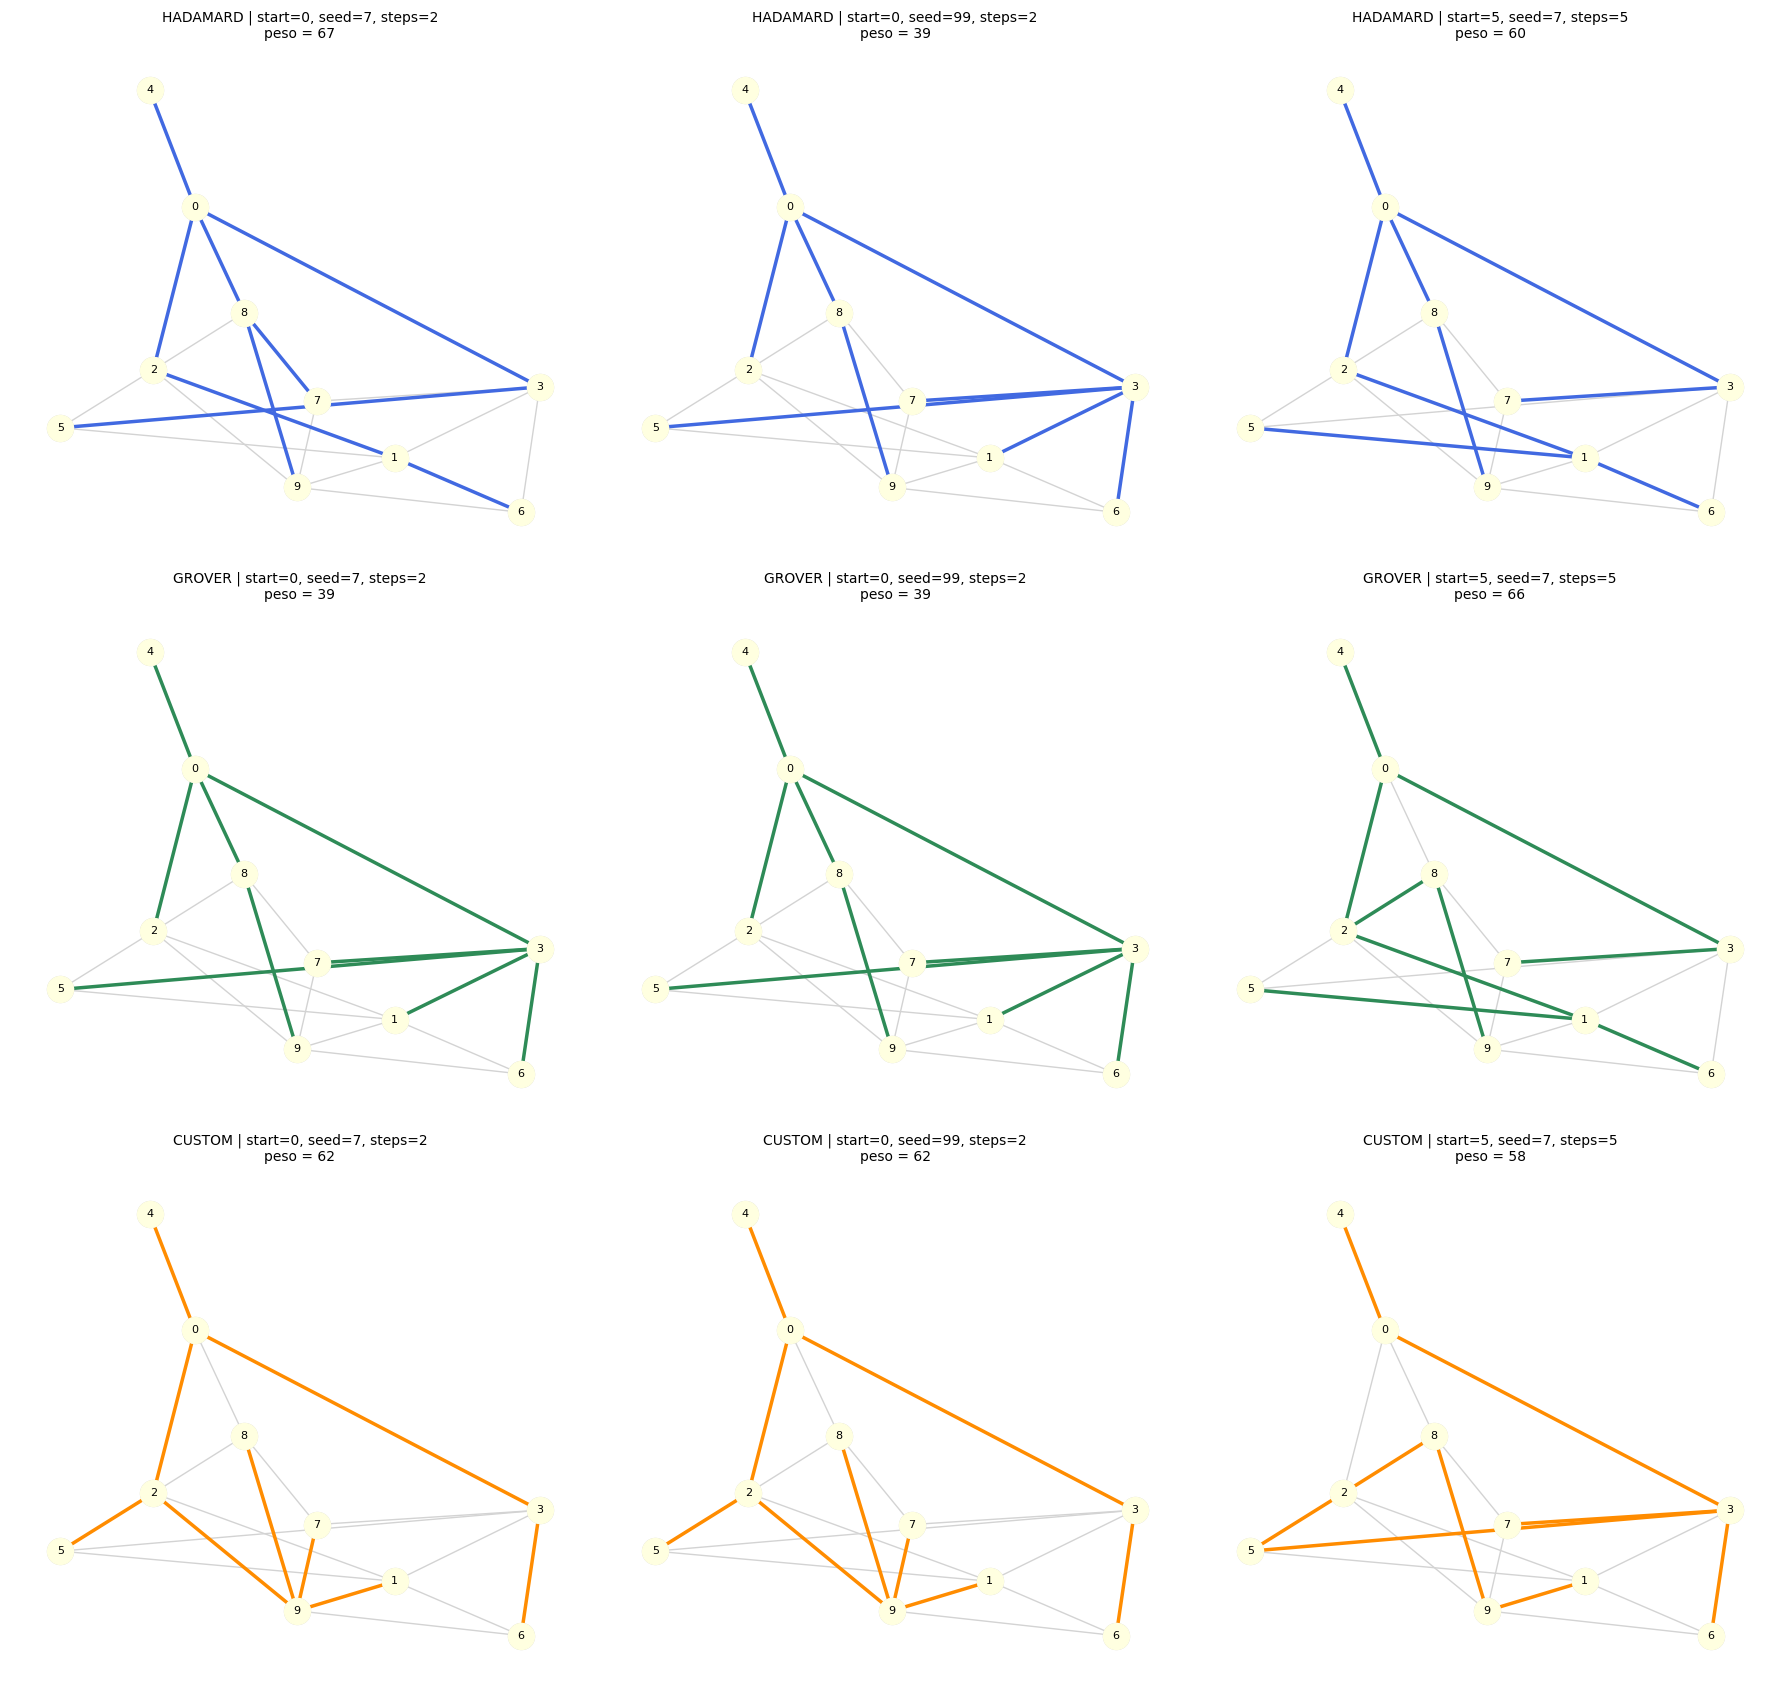

In [6]:
import numpy as np
import networkx as nx
import random
import matplotlib.pyplot as plt

SEED = 42

# ====== Grafo ponderado ======
n = 10
G = nx.erdos_renyi_graph(n, 0.35, seed=SEED)
while not nx.is_connected(G):
    SEED += 1
    G = nx.erdos_renyi_graph(n, 0.35, seed=SEED)
rng_w = random.Random(42)
for u, v in G.edges():
    G[u][v]['weight'] = rng_w.randint(1, 20)

# ====== Espaço de arcos ======
def build_arcs(G):
    arcs = []
    for u, v in G.edges():
        arcs.append((u, v)); arcs.append((v, u))
    return arcs, {a: i for i, a in enumerate(arcs)}

# ====== 3 famílias de moedas, válidas para qualquer dimensão d ======
def coin_matrix(d, coin_type):
    if coin_type == "grover":
        # moeda de Grover: reflexão em torno do vetor uniforme
        J = np.ones((d, d))
        return 2 / d * J - np.eye(d)

    elif coin_type == "hadamard":
        # generalização de Hadamard via DFT (Fourier discreto)
        # para d=2, isso é EXATAMENTE [[1,1],[1,-1]]/sqrt(2)
        w = np.exp(2j * np.pi / d)
        idx = np.arange(d)
        F = np.array([[w ** (a * b) for b in idx] for a in idx]) / np.sqrt(d)
        return F

    elif coin_type == "custom":
        # moeda customizada: permutação cíclica das direções + fase
        theta = np.pi / 4
        Cc = np.zeros((d, d), dtype=complex)
        for a in range(d):
            Cc[(a + 1) % d, a] = np.exp(1j * theta)
        return Cc

    else:
        raise ValueError(f"moeda desconhecida: {coin_type}")

def build_coin_operator(G, arcs, arc_index, coin_type):
    dim = len(arcs)
    C = np.zeros((dim, dim), dtype=complex)
    for v in G.nodes():
        out_arcs = [(v, u) for u in G.neighbors(v)]
        d = len(out_arcs)
        if d == 0:
            continue
        idxs = [arc_index[a] for a in out_arcs]
        Cv = coin_matrix(d, coin_type)
        for i, gi in enumerate(idxs):
            for j, gj in enumerate(idxs):
                C[gi, gj] = Cv[i, j]
    return C

def build_shift_operator(arcs, arc_index):
    dim = len(arcs)
    S = np.zeros((dim, dim))
    for (u, v), i in arc_index.items():
        S[arc_index[(v, u)], i] = 1
    return S

def vertex_marginal(psi, arc_index, nodes):
    probs = np.abs(psi) ** 2
    vp = {v: 0.0 for v in nodes}
    for (u, v), i in arc_index.items():
        vp[u] += probs[i]
    return vp

# ====== Construção da árvore via quantum walk (parametrizado pela moeda) ======
def quantum_tree(G, start, seed, coin_steps, coin_type):
    r = random.Random(seed)
    arcs, arc_index = build_arcs(G)
    C = build_coin_operator(G, arcs, arc_index, coin_type)
    S = build_shift_operator(arcs, arc_index)
    U = S @ C

    psi = np.zeros(len(arcs), dtype=complex)
    neigh = list(G.neighbors(start))
    d0 = len(neigh)
    for u in neigh:
        psi[arc_index[(start, u)]] = 1 / np.sqrt(d0)   # superposição inicial uniforme

    visited = {start}
    tree_edges = []

    while len(visited) < G.number_of_nodes():
        for _ in range(coin_steps):
            psi = U @ psi

        vp = vertex_marginal(psi, arc_index, G.nodes())
        frontier = [v for v in G.nodes() if v not in visited and
                    any(x in visited for x in G.neighbors(v))]
        if not frontier:
            break

        wv = np.array([vp[v] for v in frontier])
        wv = wv / wv.sum() if wv.sum() > 1e-12 else np.ones(len(frontier)) / len(frontier)

        chosen = r.choices(frontier, weights=wv, k=1)[0]
        candidates = [(x, G[chosen][x]['weight']) for x in G.neighbors(chosen) if x in visited]
        parent, wgt = min(candidates, key=lambda t: t[1])   # conecta pela aresta mais barata

        tree_edges.append((parent, chosen, wgt))
        visited.add(chosen)

    return tree_edges

# ====== 9 cenários = 3 moedas x 3 configs cada ======
coins = ["hadamard", "grover", "custom"]
base_scenarios = [
    {"start": 0, "seed": 7,  "coin_steps": 2},
    {"start": 0, "seed": 99, "coin_steps": 2},
    {"start": 5, "seed": 7,  "coin_steps": 5},
]

all_results = {}
for coin in coins:
    print(f"\n===== MOEDA: {coin.upper()} =====")
    all_results[coin] = []
    for i, sc in enumerate(base_scenarios, start=1):
        edges = quantum_tree(G, start=sc["start"], seed=sc["seed"],
                              coin_steps=sc["coin_steps"], coin_type=coin)
        weight = sum(w for _, _, w in edges)
        all_results[coin].append((sc, edges, weight))
        print(f"  Cenário {i} (start={sc['start']}, seed={sc['seed']}, "
              f"coin_steps={sc['coin_steps']}) -> peso total = {weight}")
    pesos = [w for _, _, w in all_results[coin]]
    print(f"  Pesos: {pesos}  | todos iguais? {len(set(pesos)) == 1}")

# ====== Plot: grade 3 (moedas) x 3 (cenários) ======
pos = nx.spring_layout(G, seed=42)
fig, axes = plt.subplots(3, 3, figsize=(18, 17))
colors = {"hadamard": "royalblue", "grover": "seagreen", "custom": "darkorange"}

for row, coin in enumerate(coins):
    for col, (sc, edges, weight) in enumerate(all_results[coin]):
        ax = axes[row, col]
        T = nx.Graph()
        T.add_nodes_from(G.nodes())
        T.add_weighted_edges_from(edges)

        nx.draw(G, pos, ax=ax, edge_color="lightgray", node_color="lightgray", node_size=350)
        nx.draw(T, pos, ax=ax, with_labels=True, node_color="lightyellow",
                edge_color=colors[coin], width=2.5, node_size=350, font_size=8)
        ax.set_title(f"{coin.upper()} | start={sc['start']}, seed={sc['seed']}, "
                     f"steps={sc['coin_steps']}\npeso = {weight}", fontsize=10)

plt.tight_layout()
plt.savefig("quantum_9_cenarios.png", dpi=130)
plt.show()


===== MOEDA: HADAMARD =====
  Cenário 1 (start=0, seed=7, coin_steps=2) -> peso total = 67
  Cenário 2 (start=0, seed=99, coin_steps=2) -> peso total = 39
  Cenário 3 (start=5, seed=7, coin_steps=5) -> peso total = 60
  Pesos: [67, 39, 60] | todos iguais? False

===== MOEDA: GROVER =====
  Cenário 1 (start=0, seed=7, coin_steps=2) -> peso total = 39
  Cenário 2 (start=0, seed=99, coin_steps=2) -> peso total = 39
  Cenário 3 (start=5, seed=7, coin_steps=5) -> peso total = 66
  Pesos: [39, 39, 66] | todos iguais? False

===== MOEDA: LACKADAISICAL =====
  Cenário 1 (start=0, seed=7, coin_steps=2) -> peso total = 56
  Cenário 2 (start=0, seed=99, coin_steps=2) -> peso total = 38
  Cenário 3 (start=5, seed=7, coin_steps=5) -> peso total = 56
  Pesos: [56, 38, 56] | todos iguais? False

===== MOEDA: SZEGEDY =====
  Cenário 1 (start=0, seed=7, coin_steps=2) -> peso total = 39
  Cenário 2 (start=0, seed=99, coin_steps=2) -> peso total = 39
  Cenário 3 (start=5, seed=7, coin_steps=5) -> peso t

/var/folders/kc/45xbt9r57wvfwqj69r27v_rw0000gn/T/ipykernel_33388/2733381173.py:151: RuntimeWarning: divide by zero encountered in matmul
  U = S @ C
/var/folders/kc/45xbt9r57wvfwqj69r27v_rw0000gn/T/ipykernel_33388/2733381173.py:151: RuntimeWarning: overflow encountered in matmul
  U = S @ C
/var/folders/kc/45xbt9r57wvfwqj69r27v_rw0000gn/T/ipykernel_33388/2733381173.py:151: RuntimeWarning: invalid value encountered in matmul
  U = S @ C
/var/folders/kc/45xbt9r57wvfwqj69r27v_rw0000gn/T/ipykernel_33388/2733381173.py:156: RuntimeWarning: divide by zero encountered in matmul
  step = lambda p: U @ p
/var/folders/kc/45xbt9r57wvfwqj69r27v_rw0000gn/T/ipykernel_33388/2733381173.py:156: RuntimeWarning: overflow encountered in matmul
  step = lambda p: U @ p
/var/folders/kc/45xbt9r57wvfwqj69r27v_rw0000gn/T/ipykernel_33388/2733381173.py:156: RuntimeWarning: invalid value encountered in matmul
  step = lambda p: U @ p
/var/folders/kc/45xbt9r57wvfwqj69r27v_rw0000gn/T/ipykernel_33388/2733381173.py:75

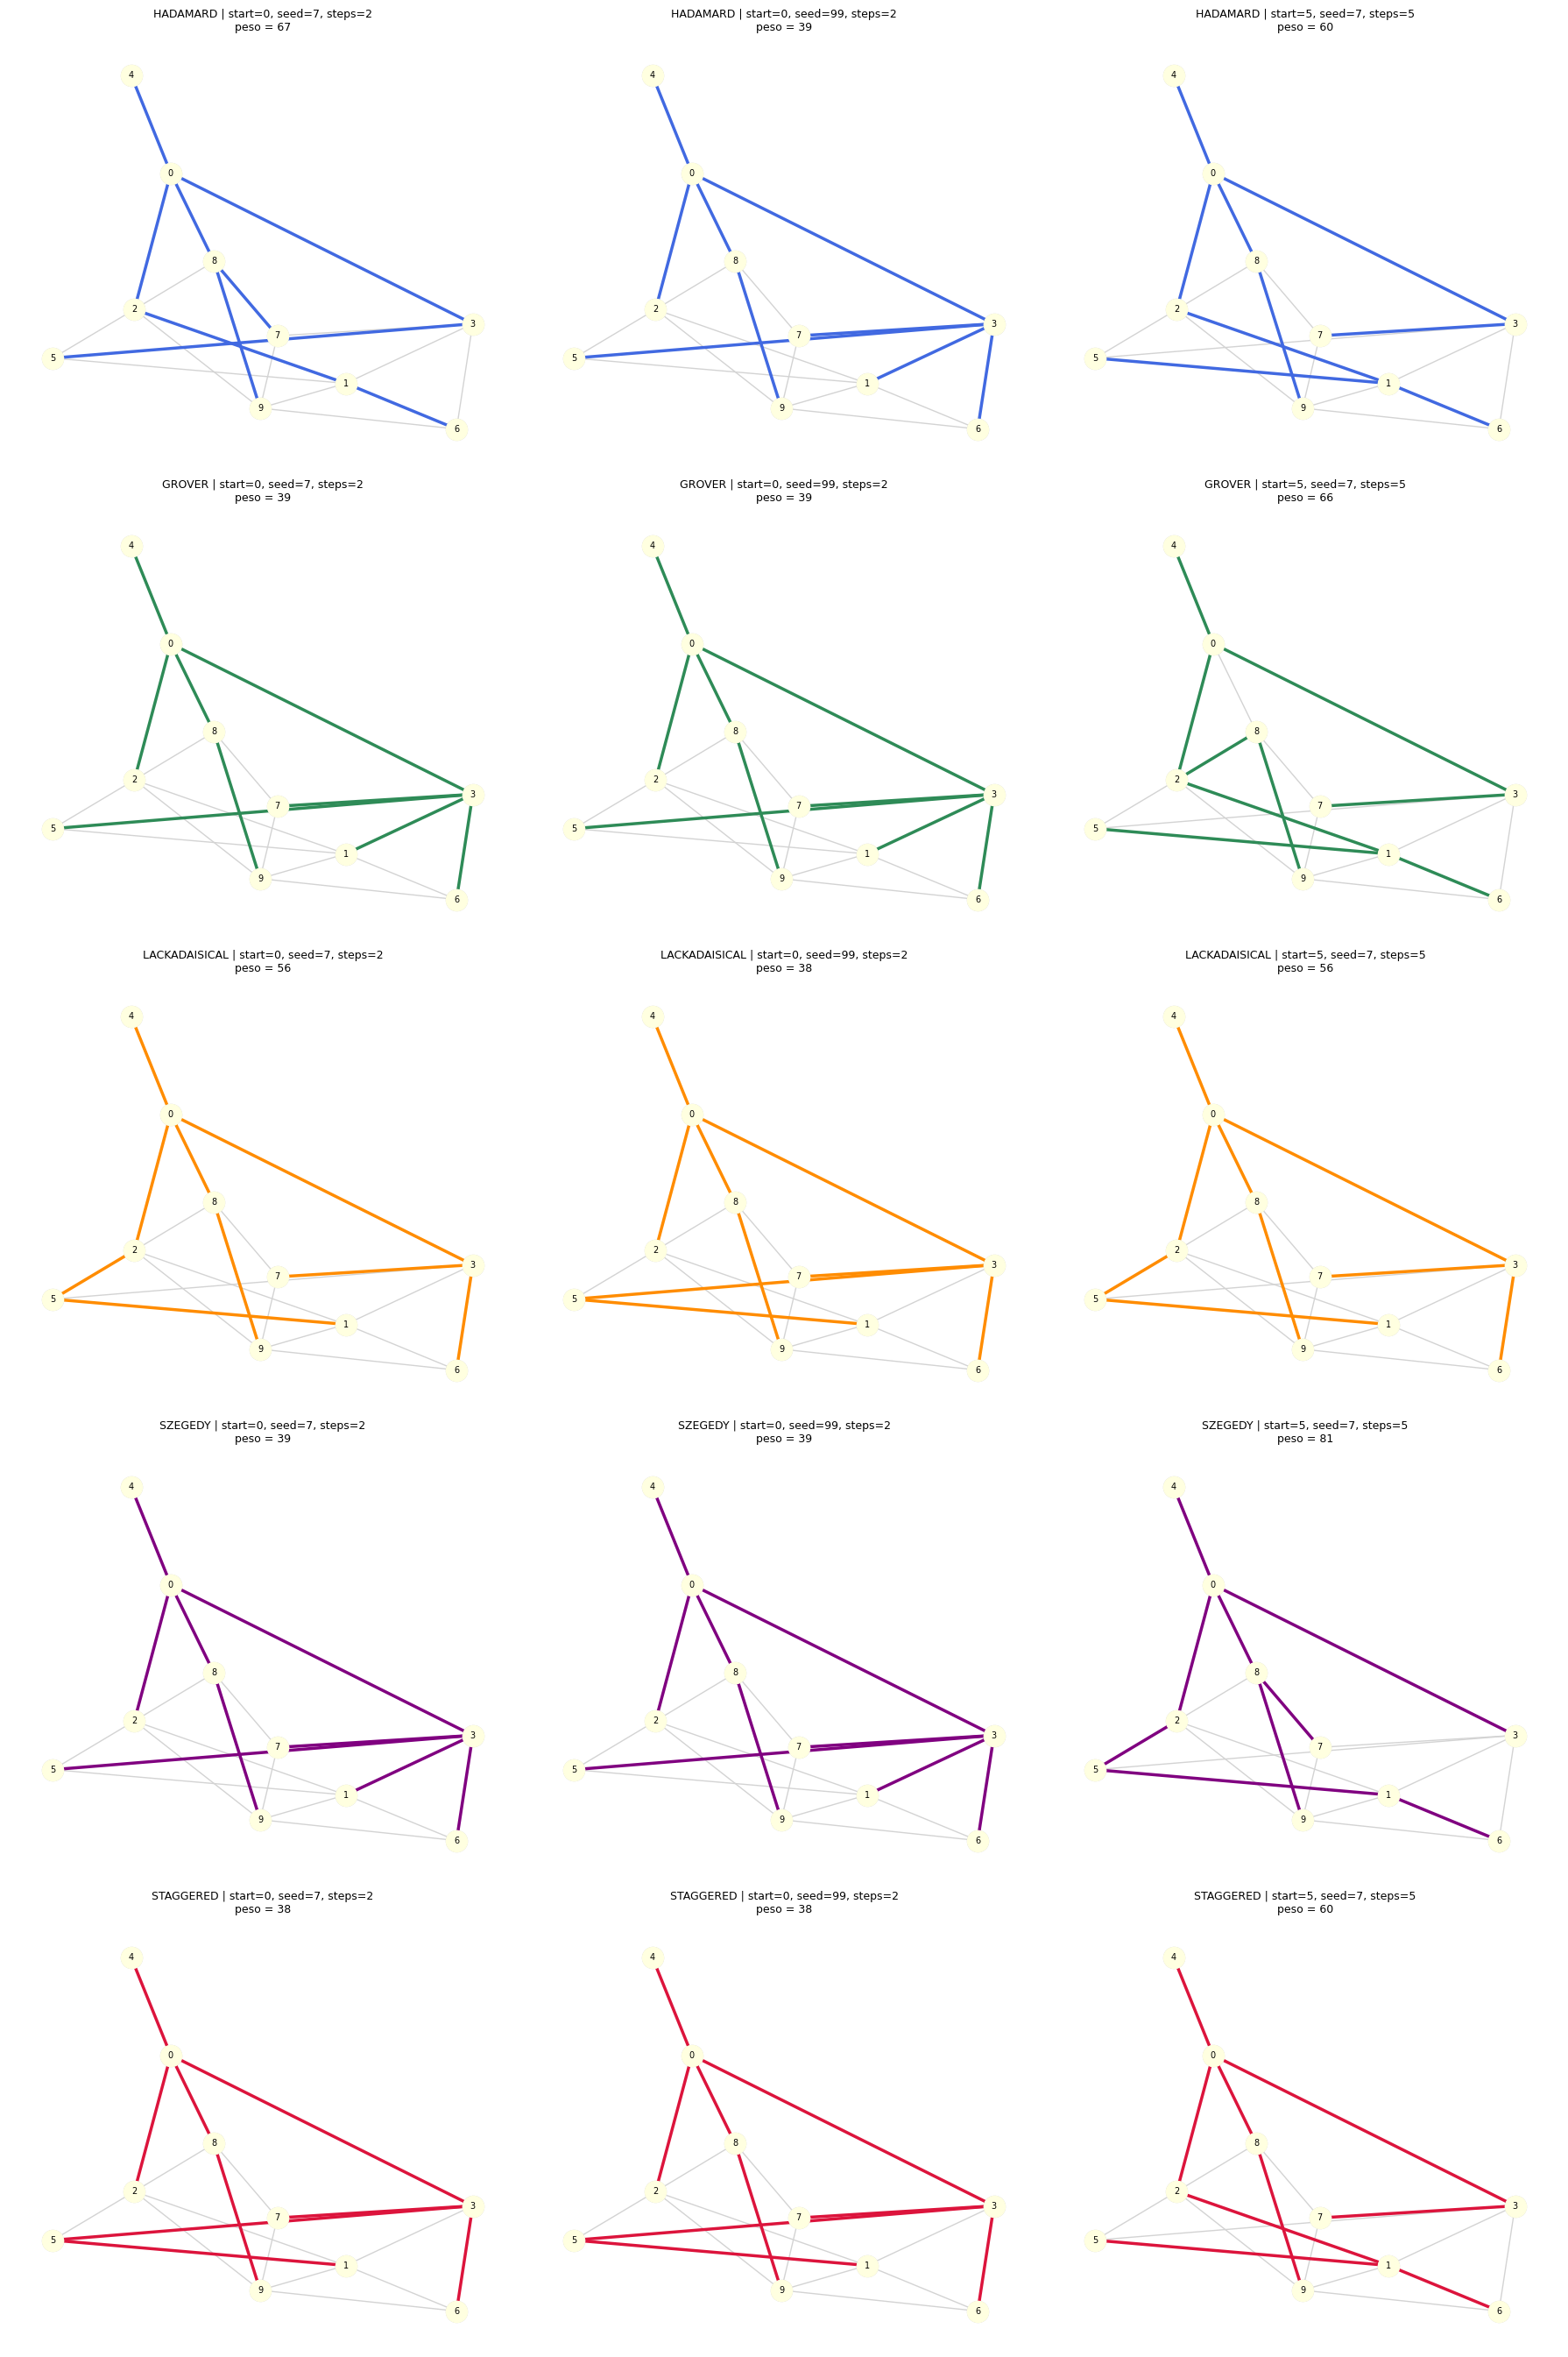

In [7]:
import numpy as np
import networkx as nx
import random
import matplotlib.pyplot as plt

# ===================== Grafo ponderado =====================
SEED = 42
n = 10
G = nx.erdos_renyi_graph(n, 0.35, seed=SEED)
while not nx.is_connected(G):
    SEED += 1
    G = nx.erdos_renyi_graph(n, 0.35, seed=SEED)
rng_w = random.Random(42)
for u, v in G.edges():
    G[u][v]['weight'] = rng_w.randint(1, 20)

NODES = list(G.nodes())
N = len(NODES)

# ===================== 1) HADAMARD e 2) GROVER (espaço de arcos) =====================
def build_arcs(G, self_loops=False):
    arcs = []
    for u, v in G.edges():
        arcs.append((u, v)); arcs.append((v, u))
    if self_loops:
        for v in G.nodes():
            arcs.append((v, v))
    return arcs, {a: i for i, a in enumerate(arcs)}

def grover_block(d):
    J = np.ones((d, d))
    return 2 / d * J - np.eye(d)

def dft_block(d):
    # generaliza Hadamard: para d=2 é EXATAMENTE [[1,1],[1,-1]]/sqrt(2)
    w = np.exp(2j * np.pi / d)
    idx = np.arange(d)
    return np.array([[w ** (a * b) for b in idx] for a in idx]) / np.sqrt(d)

def build_coin_arc(G, arcs, arc_index, block_fn, self_loops=False):
    dim = len(arcs)
    C = np.zeros((dim, dim), dtype=complex)
    for v in G.nodes():
        out_arcs = [(v, u) for u in G.neighbors(v)]
        if self_loops:
            out_arcs.append((v, v))
        d = len(out_arcs)
        if d == 0: continue
        idxs = [arc_index[a] for a in out_arcs]
        Cv = block_fn(d)
        for i, gi in enumerate(idxs):
            for j, gj in enumerate(idxs):
                C[gi, gj] = Cv[i, j]
    return C

def build_shift_arc(arcs, arc_index):
    dim = len(arcs)
    S = np.zeros((dim, dim))
    for (u, v), i in arc_index.items():
        S[arc_index[(v, u)], i] = 1     # também cobre self-loop
    return S

def vertex_marginal_arc(psi, arc_index, nodes):
    probs = np.abs(psi) ** 2
    vp = {v: 0.0 for v in nodes}
    for (u, v), i in arc_index.items():
        vp[u] += probs[i]
    return vp

# ===================== 3) LACKADAISICAL (Grover + laço próprio) =====================
def build_lackadaisical(G):
    arcs, arc_index = build_arcs(G, self_loops=True)
    C = build_coin_arc(G, arcs, arc_index, grover_block, self_loops=True)
    S = build_shift_arc(arcs, arc_index)
    return arcs, arc_index, S @ C

# ===================== 4) SZEGEDY (dimensão n x n) =====================
def build_szegedy(G):
    A = nx.to_numpy_array(G, nodelist=NODES)
    deg = A.sum(axis=1)
    P = A / deg[:, None]

    dim = N * N
    def idx(x, y): return x * N + y

    psi_vecs = np.zeros((N, dim))
    for x in range(N):
        for y in range(N):
            if P[x, y] > 0:
                psi_vecs[x, idx(x, y)] = np.sqrt(P[x, y])

    phi_vecs = np.zeros((N, dim))
    for y in range(N):
        for x in range(N):
            if P[x, y] > 0:
                phi_vecs[y, idx(x, y)] = np.sqrt(P[x, y])

    R_A = 2 * (psi_vecs.T @ psi_vecs) - np.eye(dim)
    R_B = 2 * (phi_vecs.T @ phi_vecs) - np.eye(dim)
    return psi_vecs, R_B @ R_A

def szegedy_init(psi_vecs, start_i):
    return psi_vecs[start_i].astype(complex)

def szegedy_marginal(psi):
    probs = np.abs(psi) ** 2
    mat = probs.reshape(N, N)
    col_sum = mat.sum(axis=0)          # marginal no registro y ("chegada")
    return {v: col_sum[i] for i, v in enumerate(NODES)}

# ===================== 5) STAGGERED (tesselações via matchings) =====================
def build_tessellations(G):
    H = G.copy()
    tessellations = []
    while H.number_of_edges() > 0:
        M = nx.maximal_matching(H)
        tessellations.append(list(M))
        H.remove_edges_from(M)
    return tessellations

def tessellation_unitary(tess, node_index):
    U = np.eye(N, dtype=complex)
    for (u, v) in tess:
        i, j = node_index[u], node_index[v]
        U[i, i] = 0; U[j, j] = 0
        U[i, j] = 1; U[j, i] = 1        # reflexão de Grover em dim=2 == SWAP
    return U

def build_staggered(G):
    node_index = {v: i for i, v in enumerate(NODES)}
    tess = build_tessellations(G)
    U_total = np.eye(N, dtype=complex)
    for t in tess:
        U_total = tessellation_unitary(t, node_index) @ U_total
    return U_total, len(tess)

def staggered_marginal(psi):
    probs = np.abs(psi) ** 2
    return {v: probs[i] for i, v in enumerate(NODES)}

# ===================== Construção da árvore -- interface comum =====================
def quantum_tree(G, coin_type, start, seed, coin_steps):
    r = random.Random(seed)
    node_index = {v: i for i, v in enumerate(NODES)}

    if coin_type in ("hadamard", "grover"):
        arcs, arc_index = build_arcs(G, self_loops=False)
        block_fn = dft_block if coin_type == "hadamard" else grover_block
        C = build_coin_arc(G, arcs, arc_index, block_fn, self_loops=False)
        S = build_shift_arc(arcs, arc_index)
        U = S @ C
        psi = np.zeros(len(arcs), dtype=complex)
        neigh = list(G.neighbors(start))
        for u in neigh:
            psi[arc_index[(start, u)]] = 1 / np.sqrt(len(neigh))
        step = lambda p: U @ p
        marg = lambda p: vertex_marginal_arc(p, arc_index, NODES)

    elif coin_type == "lackadaisical":
        arcs, arc_index, U = build_lackadaisical(G)
        psi = np.zeros(len(arcs), dtype=complex)
        neigh = list(G.neighbors(start))
        d1 = len(neigh) + 1
        for u in neigh:
            psi[arc_index[(start, u)]] = 1 / np.sqrt(d1)
        psi[arc_index[(start, start)]] = 1 / np.sqrt(d1)
        step = lambda p: U @ p
        marg = lambda p: vertex_marginal_arc(p, arc_index, NODES)

    elif coin_type == "szegedy":
        psi_vecs, W = build_szegedy(G)
        psi = szegedy_init(psi_vecs, node_index[start])
        step = lambda p: W @ p
        marg = szegedy_marginal

    elif coin_type == "staggered":
        U_total, _ = build_staggered(G)
        psi = np.zeros(N, dtype=complex)
        psi[node_index[start]] = 1.0
        step = lambda p: U_total @ p
        marg = staggered_marginal

    else:
        raise ValueError(coin_type)

    visited = {start}
    tree_edges = []
    while len(visited) < G.number_of_nodes():
        for _ in range(coin_steps):
            psi = step(psi)

        vp = marg(psi)
        frontier = [v for v in G.nodes() if v not in visited and
                    any(x in visited for x in G.neighbors(v))]
        if not frontier:
            break

        wv = np.array([vp[v] for v in frontier])
        wv = wv / wv.sum() if wv.sum() > 1e-12 else np.ones(len(frontier)) / len(frontier)

        chosen = r.choices(frontier, weights=wv, k=1)[0]
        candidates = [(x, G[chosen][x]['weight']) for x in G.neighbors(chosen) if x in visited]
        parent, wgt = min(candidates, key=lambda t: t[1])

        tree_edges.append((parent, chosen, wgt))
        visited.add(chosen)

    return tree_edges

# ===================== 15 cenários = 5 moedas x 3 configs =====================
coins = ["hadamard", "grover", "lackadaisical", "szegedy", "staggered"]
base_scenarios = [
    {"start": 0, "seed": 7,  "coin_steps": 2},
    {"start": 0, "seed": 99, "coin_steps": 2},
    {"start": 5, "seed": 7,  "coin_steps": 5},
]

all_results = {}
for coin in coins:
    print(f"\n===== MOEDA: {coin.upper()} =====")
    all_results[coin] = []
    for i, sc in enumerate(base_scenarios, start=1):
        edges = quantum_tree(G, coin, sc["start"], sc["seed"], sc["coin_steps"])
        weight = sum(w for _, _, w in edges)
        all_results[coin].append((sc, edges, weight))
        print(f"  Cenário {i} (start={sc['start']}, seed={sc['seed']}, "
              f"coin_steps={sc['coin_steps']}) -> peso total = {weight}")
    pesos = [w for _, _, w in all_results[coin]]
    print(f"  Pesos: {pesos} | todos iguais? {len(set(pesos)) == 1}")

# ===================== Plot: grade 5 x 3 =====================
pos = nx.spring_layout(G, seed=42)
fig, axes = plt.subplots(5, 3, figsize=(18, 27))
colors = {"hadamard": "royalblue", "grover": "seagreen", "lackadaisical": "darkorange",
          "szegedy": "purple", "staggered": "crimson"}

for row, coin in enumerate(coins):
    for col, (sc, edges, weight) in enumerate(all_results[coin]):
        ax = axes[row, col]
        T = nx.Graph()
        T.add_nodes_from(G.nodes())
        T.add_weighted_edges_from(edges)
        nx.draw(G, pos, ax=ax, edge_color="lightgray", node_color="lightgray", node_size=300)
        nx.draw(T, pos, ax=ax, with_labels=True, node_color="lightyellow",
                edge_color=colors[coin], width=2.5, node_size=300, font_size=7)
        ax.set_title(f"{coin.upper()} | start={sc['start']}, seed={sc['seed']}, "
                     f"steps={sc['coin_steps']}\npeso = {weight}", fontsize=9)

plt.tight_layout()
plt.savefig("quantum_15_cenarios.png", dpi=120)
plt.show()

In [8]:
import numpy as np
import networkx as nx
import random

# ===================== Mesmo grafo ponderado de sempre =====================
SEED = 42
n = 10
G = nx.erdos_renyi_graph(n, 0.35, seed=SEED)
while not nx.is_connected(G):
    SEED += 1
    G = nx.erdos_renyi_graph(n, 0.35, seed=SEED)
rng_w = random.Random(42)
for u, v in G.edges():
    G[u][v]['weight'] = rng_w.randint(1, 20)

# ===================== MST exata (referência) =====================
class UnionFind:
    def __init__(self, nodes):
        self.parent = {v: v for v in nodes}
    def find(self, x):
        while self.parent[x] != x:
            self.parent[x] = self.parent[self.parent[x]]
            x = self.parent[x]
        return x
    def union(self, a, b):
        ra, rb = self.find(a), self.find(b)
        if ra == rb: return False
        self.parent[ra] = rb
        return True

def kruskal_mst(G):
    edges = sorted(G.edges(data=True), key=lambda e: e[2]['weight'])
    uf = UnionFind(G.nodes())
    total = 0
    for u, v, data in edges:
        if uf.union(u, v):
            total += data['weight']
    return total

MST_OPTIMAL = kruskal_mst(G)

# ===================== TESTE DE CONTROLE: "Prim aleatório" =====================
# Igual ao algoritmo quântico (conecta pelo vizinho MAIS BARATO já visitado),
# mas o vértice da fronteira é escolhido por sorteio UNIFORME -- sem coin,
# sem amplitude, sem interferência. Isola o efeito real do "quantum" no resultado.
def random_prim(G, seed):
    r = random.Random(seed)
    start = r.choice(list(G.nodes()))
    visited = {start}
    total_weight = 0

    while len(visited) < G.number_of_nodes():
        frontier = [v for v in G.nodes() if v not in visited and
                    any(x in visited for x in G.neighbors(v))]
        if not frontier:
            break
        chosen = r.choice(frontier)                       # <- sorteio uniforme, sem coin
        candidates = [(x, G[chosen][x]['weight']) for x in G.neighbors(chosen) if x in visited]
        parent, wgt = min(candidates, key=lambda t: t[1])  # mesmo passo guloso do quantum
        total_weight += wgt
        visited.add(chosen)

    return total_weight

N_TRIALS = 500
random_weights = [random_prim(G, seed=s) for s in range(N_TRIALS)]

mean_r = np.mean(random_weights)
std_r  = np.std(random_weights)
min_r, max_r = min(random_weights), max(random_weights)

print(f"MST ótima (Kruskal):              {MST_OPTIMAL}")
print(f"Prim aleatório ({N_TRIALS} runs):  média={mean_r:.1f}  desvio={std_r:.1f}  "
      f"min={min_r}  max={max_r}")

# ===================== Resultados quânticos já obtidos (para comparação) =====================
quantum_results = {
    "hadamard":      [67, 39, 60],
    "grover":        [39, 39, 66],
    "lackadaisical": [56, 38, 56],
    "szegedy":       [39, 39, 81],
    "staggered":     [38, 38, 60],
}
quantum_all = [w for vals in quantum_results.values() for w in vals]
mean_q = np.mean(quantum_all)
std_q  = np.std(quantum_all)

print(f"\nQuantum walks (15 amostras):       média={mean_q:.1f}  desvio={std_q:.1f}  "
      f"min={min(quantum_all)}  max={max(quantum_all)}")

# ---- comparação estatística simples ----
z = (mean_q - mean_r) / (std_r / np.sqrt(N_TRIALS))
print(f"\nz-score da média quântica frente à distribuição de controle: {z:.2f}")
print("(|z| < ~2 sugere que a média quântica é estatisticamente indistinguível do acaso puro)")

pct_better_or_equal = 100 * np.mean(np.array(random_weights) <= mean_q)
print(f"{pct_better_or_equal:.1f}% dos runs de Prim aleatório tiveram peso <= média quântica ({mean_q:.1f})")

MST ótima (Kruskal):              31
Prim aleatório (500 runs):  média=47.7  desvio=11.6  min=31  max=81

Quantum walks (15 amostras):       média=50.3  desvio=13.7  min=38  max=81

z-score da média quântica frente à distribuição de controle: 5.05
(|z| < ~2 sugere que a média quântica é estatisticamente indistinguível do acaso puro)
66.8% dos runs de Prim aleatório tiveram peso <= média quântica (50.3)
